In [ ]:
!pip install efficientnet_pytorch timm pretrainedmodels


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=ae639bf5e87053967ab6b45c6a75a6a80baf6d4825b2186093e01f03f487424a
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=a083c55e05e4d067487dfda47971572585f1ed863063b5cb00086e24fbc681b1
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built efficientnet_pytorch pretrainedmodels


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report


In [ ]:
import os
import torch

def save_best_model(model, model_name="model"):
    """
    Saves the trained model both in /content and Google Drive.
    Automatically creates folders if they don't exist.
    """
    # Local runtime save
    local_path = f"{model_name}_best.pth"
    torch.save(model.state_dict(), local_path)

    # Google Drive directory
    drive_dir = "/content/drive/MyDrive/brain_tumor_project/models/classification/"
    os.makedirs(drive_dir, exist_ok=True)

    # Final destination
    drive_path = os.path.join(drive_dir, f"{model_name}_best.pth")

    # Copy file
    !cp "{local_path}" "{drive_path}"

    print(f"✓ Saved BEST {model_name} model to:")
    print(drive_path)


In [ ]:
class MRIClassifierDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = []
        self.labels = []
        self.transform = transform

        self.classes = ["1", "2", "3", "no_tumor"]
        self.class_to_idx = {cls:i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            folder = os.path.join(root_dir, cls)
            for img_name in os.listdir(folder):
                self.paths.append(os.path.join(folder, img_name))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224,224))

        img = np.stack([img, img, img], axis=2)  # grayscale → 3ch

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return img, label


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

DATA_ROOT = "/content/drive/MyDrive/brain_tumor_project/data/enhanced/unet"

train_ds = MRIClassifierDataset(DATA_ROOT + "/train", transform)
val_ds   = MRIClassifierDataset(DATA_ROOT + "/val", transform)
test_ds  = MRIClassifierDataset(DATA_ROOT + "/test", transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))


2213 635 314


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    model.train()
    return correct / total

def test_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\n🔍 Test Classification Report:\n")
    print(classification_report(y_true, y_pred))


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128*28*28, 256), nn.ReLU(),
            nn.Linear(256, 4)
        )
    def forward(self,x): return self.net(x)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ========================
#  CNN TRAINING CODE
# ========================

train_acc_list = []
val_acc_list = []
train_loss_list = []

best_acc = 0
patience = 5
no_improve = 0

def train_cnn():
    global best_acc, no_improve

    for epoch in range(50):
        model.train()
        correct = 0
        total = 0
        running_loss = 0

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        # Compute epoch metrics
        train_acc = correct / total
        train_loss = running_loss / total
        val_acc = evaluate(model, val_loader)

        # Store metrics
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            no_improve = 0
            save_best_model(model, "cnn")
            print("✓ Saved best model")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break

    print("\nTraining complete.")



In [ ]:
# ---- Run training ----
train_cnn()

# ---- Load best model ----
model.load_state_dict(torch.load("cnn_best.pth"))
print("\n🔥 Loaded Best CNN Model for testing.")

# ---- Final Test ----
test_model(model, test_loader)

100%|██████████| 139/139 [00:21<00:00,  6.34it/s]


Epoch 1 | Train Acc: 0.6941 | Val Acc: 0.7669
✓ Saved BEST cnn model to:
/content/drive/MyDrive/brain_tumor_project/models/classification/cnn_best.pth
✓ Saved best model


100%|██████████| 139/139 [00:24<00:00,  5.59it/s]


Epoch 2 | Train Acc: 0.8292 | Val Acc: 0.8079
✓ Saved BEST cnn model to:
/content/drive/MyDrive/brain_tumor_project/models/classification/cnn_best.pth
✓ Saved best model


100%|██████████| 139/139 [00:25<00:00,  5.43it/s]


...

Epoch 21 | Train Acc: 1.0000 | Val Acc: 0.9449


100%|██████████| 139/139 [00:21<00:00,  6.45it/s]


Epoch 22 | Train Acc: 1.0000 | Val Acc: 0.9417


100%|██████████| 139/139 [00:21<00:00,  6.42it/s]


Epoch 23 | Train Acc: 1.0000 | Val Acc: 0.9386
⛔ Early stopping at epoch 23

Training complete.

🔥 Loaded Best CNN Model for testing.

🔍 Test Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        75
           1       0.90      0.90      0.90       139
           2       0.97      0.95      0.96        94
           3       1.00      1.00      1.00         6

    accuracy                           0.89       314
   macro avg       0.91      0.91      0.91       314
weighted avg       0.90      0.89      0.90       314



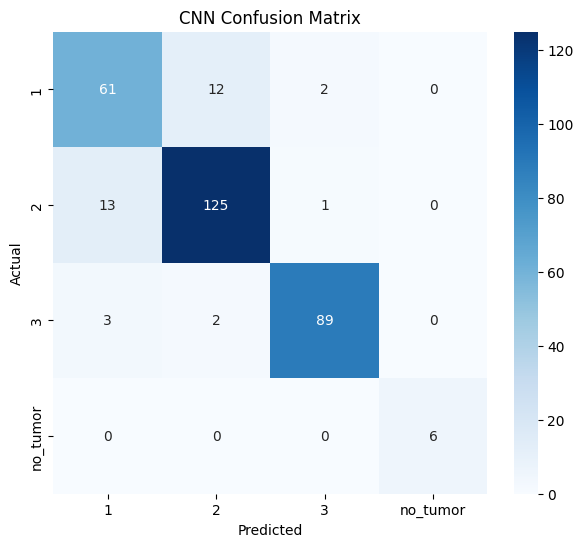

In [ ]:
#------------------Generate Confusion Matrix-------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure best model is loaded
model.load_state_dict(torch.load("cnn_best.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1","2","3","no_tumor"],
            yticklabels=["1","2","3","no_tumor"])
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
#----Compute Specificity for Each Class
#  Specificity = TN / (TN + FP)

import numpy as np

cm = confusion_matrix(y_true, y_pred)
specificity = {}

for i, cls in enumerate(["1","2","3","no_tumor"]):
    TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    FP = cm[:,i].sum() - cm[i,i]
    specificity[cls] = TN / (TN + FP)

print("Specificity per class:")
for cls, spec in specificity.items():
    print(cls, ":", round(spec, 4))


Specificity per class:
1 : 0.9331
2 : 0.92
3 : 0.9864
no_tumor : 1.0


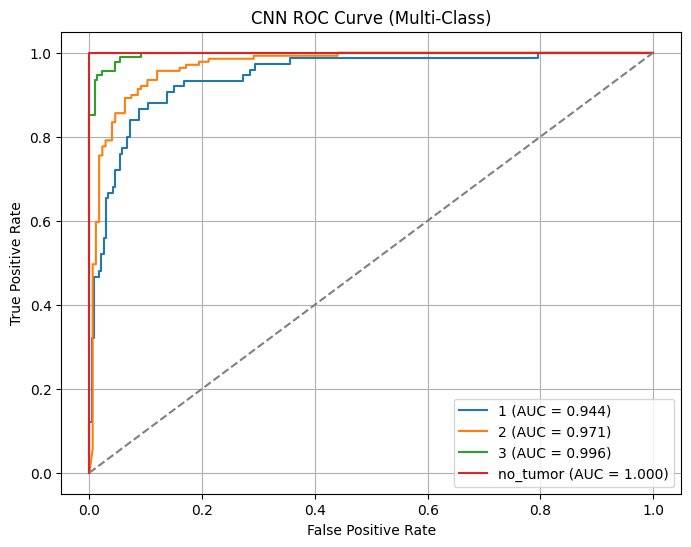

In [ ]:
#-----------ROC Curve for Multi-Class

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model.eval()

y_true = []
y_score = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_score.extend(probs)

y_true_onehot = label_binarize(y_true, classes=[0,1,2,3])
y_score = np.array(y_score)

plt.figure(figsize=(8,6))

for i, cls in enumerate(["1","2","3","no_tumor"]):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],"--", color="gray")
plt.title("CNN ROC Curve (Multi-Class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


In [ ]:
#------------------Print Final Metrics Table----

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n=== CNN FINAL METRICS ===")
print("Accuracy:      ", round(acc,4))
print("Precision:     ", round(prec,4))
print("Recall:        ", round(rec,4))
print("F1 Score:      ", round(f1,4))

print("\nSpecificity per class:", specificity)



=== CNN FINAL METRICS ===
Accuracy:       0.8949
Precision:      0.896
Recall:         0.8949
F1 Score:       0.8954

Specificity per class: {'1': np.float64(0.9330543933054394), '2': np.float64(0.92), '3': np.float64(0.9863636363636363), 'no_tumor': np.float64(1.0)}
